<a href="https://colab.research.google.com/github/mglavan07/HYDAC_Capacity_Forecasting_Models/blob/main/ClusterSibligs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Download dataseparation.py and upload it here!

In [195]:
# gather the functions from DataSeparation
from google.colab import files
uploaded = files.upload()

Saving dataseparation.py to dataseparation (2).py


In [196]:
# import the data loader
from dataseparation import directory_to_precluster

Now, select and load the data for your heirarchy!

In [197]:
# call to precluster formatting
data = directory_to_precluster(sort_rev=True)

Saving 16_05_05_ELD_21stCenturySales.XLSX to 16_05_05_ELD_21stCenturySales.XLSX


In [198]:
# define a function to normalize features knowing there are severe outliers
def normalize_features(df):

    try:
        import pandas as pd
        # copy the original DataFrame
        norm = df.copy()

        # total quantity min-max scaled
        norm["Total Quantity"] = (df["Total Quantity"] - df["Total Quantity"].min()) / (df["Total Quantity"].max() - df["Total Quantity"].min())

        # total revenue min-max scaled
        norm["Total Revenue"] = (df["Total Revenue"] - df["Total Revenue"].min()) / (df["Total Revenue"].max() - df["Total Revenue"].min())

        # total cost min-max scaled
        norm["Total Cost"] = (df["Total Cost"] - df["Total Cost"].min()) / (df["Total Cost"].max() - df["Total Cost"].min())

        # return the new dataframe
        return norm

    # flag errors
    except KeyError:
        print(f"Error: not all columns located")
        return pd.DataFrame()
    except ModuleNotFoundError:
        print("Error: pandas is not installed.")
        return pd.DataFrame()
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
        return pd.DataFrame()

In [199]:
# define a function to run a DBSCAN
def dbscan_cluster(norm_data, param1_eps, param2_msamp):

    try:
        # import machine learning packages
        import pandas as pd
        import numpy as np
        from sklearn.cluster import DBSCAN

        # feature matrix (Nx3)
        X = norm_data[['Total Quantity', 'Total Revenue', 'Total Cost']]

        # neighborhood radius of and min samples to be optimzed
        db = DBSCAN(eps = param1_eps, min_samples = param2_msamp)
        clusters = db.fit_predict(X)

        # append the resulting column vector (Nx1)
        norm_data['Cluster'] = clusters

        # return the updated dataframe
        return norm_data

    # flag errors
    except KeyError:
        print(f"Error: not all columns located")
        return pd.DataFrame()
    except ModuleNotFoundError:
        print("Error: libraries is not installed. sklearn, pandas, numpy required")
        return pd.DataFrame()
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
        return pd.DataFrame()

In [200]:
# define a function to visualize results
def visualize_results(df):

  # import data visualization modules
  from mpl_toolkits.mplot3d import Axes3D
  import matplotlib.pyplot as plt
  import seaborn as sns
  from sklearn.metrics import silhouette_samples, silhouette_score
  import matplotlib.pyplot as plt
  import matplotlib.cm as cm
  import numpy as np
  import plotly.express as px
  from sklearn.metrics import davies_bouldin_score

  # Create a 3D Scatter Plot
  df['Cluster'] = df['Cluster'].astype(str)

  fig = px.scatter_3d(
      df,
      x='Total Quantity',
      y='Total Revenue',
      z='Total Cost',
      color='Cluster',
      hover_data=['Material'],
      title='3D DBSCAN Clustering: Interactive Plot'
  )

  # Set initial view with the origin
  fig.update_layout(
      scene=dict(
          xaxis_title='Total Quantity',
          yaxis_title='Total Revenue',
          zaxis_title='Total Cost',
          camera=dict(
              eye=dict(x=-1.6, y=-1.6, z=0.4)  # facing origin
          )
      )
  )

  fig.show()

  # Compute correlation matrix between numeric columns
  corr = df[['Total Quantity', 'Total Revenue', 'Total Cost']].corr()

  plt.figure(figsize=(8, 6))
  sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=0, vmax=1)
  plt.title("Feature Correlation Heatmap")
  plt.show()

  # Present a pair plot
  sns.pairplot(
      df,
      vars=['Total Quantity', 'Total Revenue', 'Total Cost'],
      hue='Cluster',
      palette='Set1',
      diag_kind='kde'
  )

  plt.suptitle("DBSCAN Clusters — Pairwise KDE Plots", y=1.02)
  plt.show()

  # Use same features as clustering input
  X = df[['Total Quantity', 'Total Revenue', 'Total Cost']]
  labels = df['Cluster']

  # Compute average scores
  score = silhouette_score(X, labels)
  print(f"Average silhouette score: {score:.4f}")

  DBI = davies_bouldin_score(X, labels)
  print(f"Davies-Bouldin Index: {DBI:.4f}")


In [201]:
# define a function that runs parameters to find the best sihloette score
def optimize_SHS(data):
  try:

    # import libraries for model scoring
    import pandas as pd
    import numpy as np
    from sklearn.metrics import silhouette_score, silhouette_samples
    from sklearn.cluster import DBSCAN
    from sklearn.metrics import davies_bouldin_score

    # set ranges
    eps_min = 0.01
    eps_max = 0.5
    eps_step = 0.01
    samples_min = 1
    samples_max = 10
    samples_step = 1

    # feature matrix
    X = data[['Total Quantity', 'Total Revenue', 'Total Cost']]

    # record performance in lists
    SILs = []
    DBIs = []
    params = []

    # iterate through all the ranges
    for eps in np.arange(eps_min, eps_max, eps_step):
        for samples in range(samples_min, samples_max, samples_step):

          # make the clustering model with the specified parameters
          db = DBSCAN(eps=eps, min_samples = samples)
          clusters = db.fit_predict(X)

          # append the resulting column vector (Nx1)
          temp = data.copy()
          temp['Cluster'] = clusters

          # Use same features as clustering input
          labels = temp['Cluster']

          # Compute scores
          score = silhouette_score(X, labels)
          DBI = davies_bouldin_score(X, labels)

          # append to lists
          SILs.append(score)
          DBIs.append(DBI)
          params.append((eps, samples))

    # normalize SIL and DBI scores for population
    SILs = (SILs - np.min(SILs)) / (np.max(SILs) - np.min(SILs))
    DBIs = (DBIs - np.min(DBIs)) / (np.max(DBIs) - np.min(DBIs))

    # Convert to DataFrame for ranking
    results = pd.DataFrame({
        'Params': params,
        'Silhouette': SILs,
        'DBI': DBIs
    })

    # Rank Silhouette (higher is better), DBI (lower is better)
    results['Sil_Rank'] = results['Silhouette'].rank(ascending=False)
    results['DBI_Rank'] = results['DBI'].rank(ascending=True)
    results['Total_Rank'] = results['Sil_Rank'] + results['DBI_Rank']

    # Select best (lowest total rank)
    best_idx = results['Total_Rank'].idxmin()
    best_row = results.loc[best_idx]

    # print and return the optimal values
    print(f"Best Parameters: eps={best_row['Params'][0]:.2f}, min_samples={int(best_row['Params'][1])}")
    return best_row['Params'][0], best_row['Params'][1]

  # eror flaging, return defaults
  except KeyError:
    print(f"Error: not all columns located")
    return 0.3, 1
  except ModuleNotFoundError:
    print("Error: libraries is not installed. sklearn, pandas, numpy required")
    return 0.3, 1
  except Exception as e:
    print(f"An unexpected error occurred: {e}")
    return 0.3, 1

In [204]:
# define a function to complete all steps in one call
def cluster_heirarchy(data):
    norm_data = normalize_features(data)
    eps_op, samples_op = optimize_SHS(norm_data)
    clustered_data = dbscan_cluster(norm_data, eps_op, samples_op)
    visualize_results(clustered_data)
    return clustered_data

**Test the model!**

**3D Plot** - Displays spatially where normalized sample data lies. The plot is color encoded to represent the buckets each material belongs to. Some important things to check for is a "normal" number of clusters (2 - 5), the location of each cluster, and the amount of materials belonging to each cluster. Over time, we would expect cluters along the line from (0,0,0) to (1,1,1) with more points lying at the origin.

**Feature Correlation Heatmap** - Displays "how related" two features are for the dataset. Warm areas mean the row and column are near directly related, cooler areas mean the row and column are non-related. By definition, elements on the main diagonal will be 1 (a feature is related to itself). Over time, we would expect cost and revenue to be very closely related, and a more linear cluster would have a high correlation with quantity. Simply put, oftentimes we will find all features to be closely correlated, which means a material is either a large contributor to the revenue AND capacity, or a small contributor to both.

**Pairwise Plots** - Diagonal elements displays the distribution of a single feature, and each cell in the grid is a scatter plot between the two features. In this plot, we are looking for plots on the main diagonal that are clearly separated e.g. no overlapping areas. On off-diagonal scatter plots, a strong model is characterized with cluter assignments on each scatter that "make sense." If one scatter plot is particularly noisy or inaccurate, it is likely that feature is messy.

**Sihloette Score** - A numerical rating of how well each point fits into its asigned cluster. This metric ranges from -1 to 1, where positive scores indicate a strong model and negative scores indicate the model was incorrect.

**DBI Score** - Represents how tight and well-separated clusters are. Anything under 0.3 is considered acceptable, and the smaller the better.

Best Parameters: eps=0.10, min_samples=1


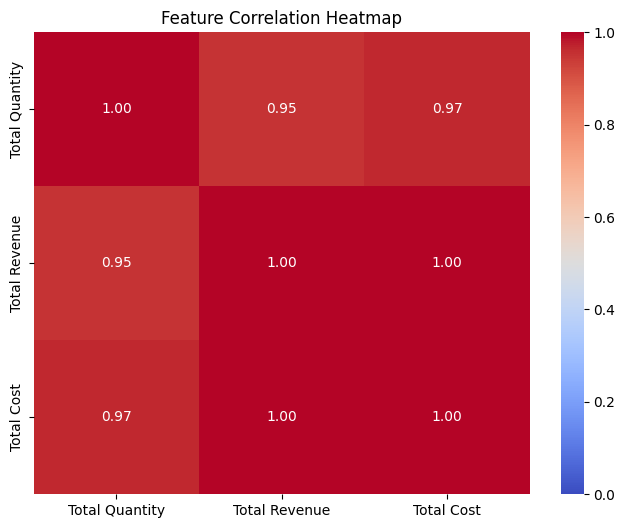

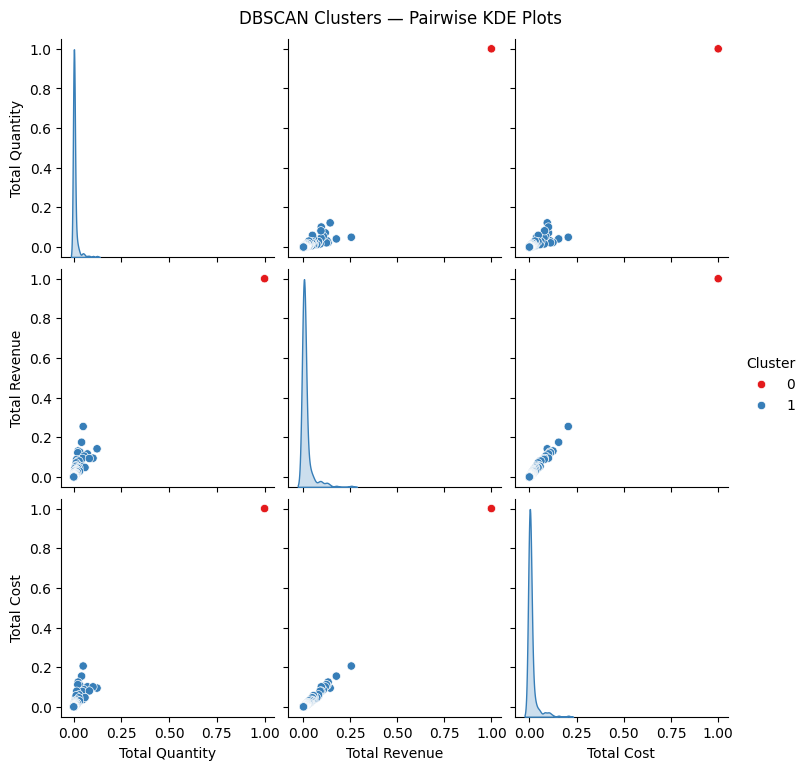

Average silhouette score: 0.9782
Davies-Bouldin Index: 0.0140


In [205]:
Y = cluster_heirarchy(data)